### 自然言語処理

画像認識は、もともと画像データが多次元ベクトルとして、よく似た画像が近いベクトルで表現されるなど、機械学習で処理しやすい前提が整っている。

一方、自然言語などのテキストは、文字コードが近くても意味が近いわけではない。


自然言語を機械学習で処理するためには、テキストの特徴量を多次元ベクトルでうまく表現することが鍵になる。

### 携帯要素解析
言語における意味の基本単位は __語(word)__ 。

#### 英語と日本語
自然言語処理は、言語の種類によって難しさや扱い方が異なる。

- (英語文) I bought a book
- (日本語文) 私は本を買った

英語は、空白で区切られたものを語と考えることができる。
したがって、Python の標準文字列ライブラリだけで、簡単に語を取り出すことができる。

日本語では、まず語の区切りを判定する必要がある。

しかし、この語の区切りを判定するのがかなりの難処理となる。

そこで、専用のツール/ライブラリが必要。

### spaCy/GINZA

spaCy は、Explosion AI 社の開発するオープンソースの自然言語処理ライブラリ。
2019 年に、 リクルート AI 研究所と国立言語研究所の研究成果である GiNZA が登場し、実用的な日本語処理が手軽に利用できるようになった。



In [7]:
# 形態素解析による字句解析
import spacy

# spaCy / GiNZA のバージョン差異で compound_splitter の設定エラーが出る場合の回避
nlp = spacy.load("ja_ginza", exclude=["compound_splitter"])

doc = nlp("私は本を買った") #形態素解析


for word in doc:
    print(word.i, word.orth_, word.lemma_, word.pos_, word.tag_)


0 私 私 PRON 代名詞
1 は は ADP 助詞-係助詞
2 本 本 NOUN 名詞-普通名詞-一般
3 を を ADP 助詞-格助詞
4 買っ 買う VERB 動詞-一般
5 た た AUX 助動詞


In [8]:
# 日本語文を安吾単位に分割する関数を定義
import spacy

# spaCy / GiNZA のバージョン差異で compound_splitter の設定エラーが出る場合の回避
nlp = spacy.load("ja_ginza", exclude=["compound_splitter"])


def wakachi(s):
    doc = nlp(s)
    return [word.lemma_ for word in doc]  # word.lemma_ は標準形

print(wakachi('私は本を買った'))

['私', 'は', '本', 'を', '買う', 'た']


### 感想文の分析

In [10]:
# データの確認
import pandas as pd

df = pd.read_csv('./data/movie2024.csv')

df.head()

,映画タイトル,感想,評価,泣ける,笑える,勉強,キュキュン,怖い,ワクワク,ハラハラ
0,ウィッシュ,ディズニー100周年の集大成。2Dと3Dの融合で今までにない映像。,5,5,4,4,0,3,5,4
1,ダンジョンズ&ドラゴンズ,世界発のRPGが題材の作品。ユニークでおもしろい,4,3,4,1,3,2,5,5
2,鬼誕生 ゲゲゲの謎,なんとなく大人向けで怖くておもしろい,4,3,2,2,1,4,4,5
3,タイタニック,とても泣ける。純愛で感動した。,5,5,2,3,5,5,5,5
4,パリピ公明 アニメ総集編,懐かしの音楽が劇場音響で聞けて最高,3,1,3,1,1,1,5,2


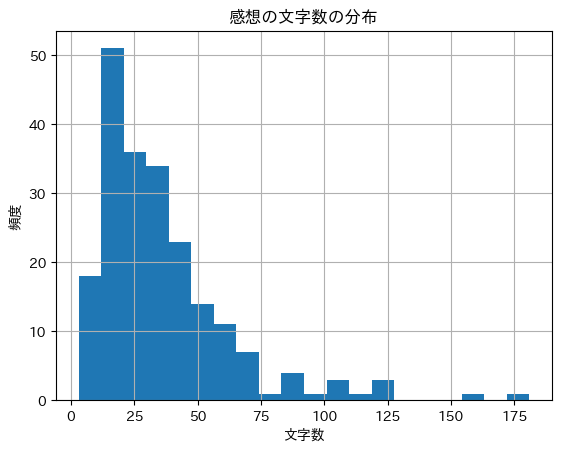

In [ ]:
# 文字数をカウント

# データの確認
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

df = pd.read_csv('./data/movie2024.csv')

df["文字数"] = df["感想"].str.len() # 感想の文字数をカウントして新しい列「文字数」を作成

# 文字数の分布をヒストグラムで表示
plt.hist(df["文字数"], bins=20)
plt.grid()
plt.xlabel("文字数")
plt.ylabel("頻度")
plt.title("感想の文字数の分布")
plt.show()
